# U.S. Medical Insurance Costs--Step5 Log-transform to improve linearity

In [9]:
# From residual plot, I observed that the model does not fit the data well, showing clear non-linearity and heteroscedasticity. Therefore, I decided to apply a log transformation to the target variable to improve model fit.
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [10]:
# Read the CSV file
ins_cleaned_df = pd.read_csv("/Users/shenkong/Desktop/Projects/pj02_US_Medical_Insurance_Costs/data/ins_cleaned.csv")

In [11]:
# Redefine X and y
df_encoded = pd.get_dummies(ins_cleaned_df, drop_first=True)
df_encoded["log_charges"] = np.log(df_encoded["charges"])

df_encoded[["charges", "log_charges"]].describe()

X_log = df_encoded[[
    "age",
    "bmi",
    "children",
    "smoker_yes"
]].astype(float)

X_log = sm.add_constant(X_log)
y_log = df_encoded["log_charges"]

In [12]:
# Fit regression model on log-transformed target
log_model = sm.OLS(y_log, X_log).fit()

log_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_charges   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1065.
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        11:30:59   Log-Likelihood:                -824.09
No. Observations:                1337   AIC:                             1658.
Df Residuals:                    1332   BIC:                             1684.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9850      0.070    100.173      0.000       6.848       7.122
age            0.0347      0.001     39.431      0.000       0.033       0.036
bmi            0.0106      0.002      5.242      0.000       0.007       0.015
children       0.1009      0.010      9.893      0.000       0.081       0.121
smoker_yes     1.5427      0.030     50.690      0.000       1.483       1.602
==============================================================================
Omnibus:                      441.587   Durbin-Watson:                   2.055
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1547.107
Skew:                           1.603   Prob(JB):                         0.00
Kurtosis:                       7.182   Cond. No.                         292.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
# Make prediction based on the original data (inverse log transformation):
y_log_pred = log_model.predict(X_log)

# Inverse log transformation:
y_pred_original = np.exp(y_log_pred)  # Convert log-scale predictions back to the original charges scale
y_original = df_encoded["charges"]

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
mae_log = mean_absolute_error(y_original, y_pred_original)
rmse_log = np.sqrt(
    mean_squared_error(y_original, y_pred_original)
)

print(f"MAE: {mae_log}")
print(f"RMSE: {rmse_log}")

MAE: 4227.538340108185
RMSE: 8281.830465817511


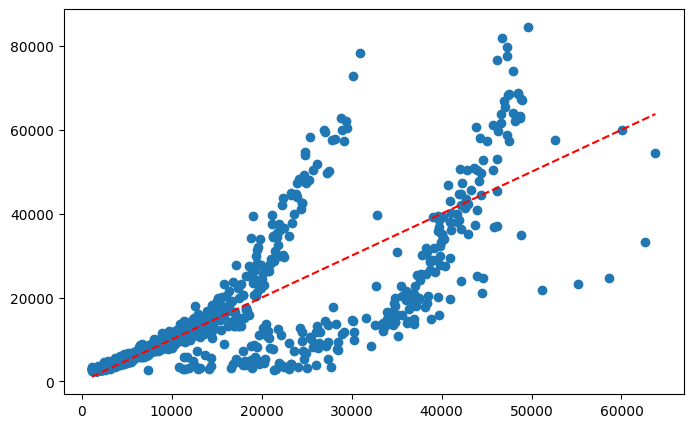

In [14]:
# Create the plots
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(df_encoded["charges"], y_pred_original)

plt.plot(
    [df_encoded["charges"].min(), df_encoded["charges"].max()],
    [df_encoded["charges"].min(), df_encoded["charges"].max()],
    "r--"
)

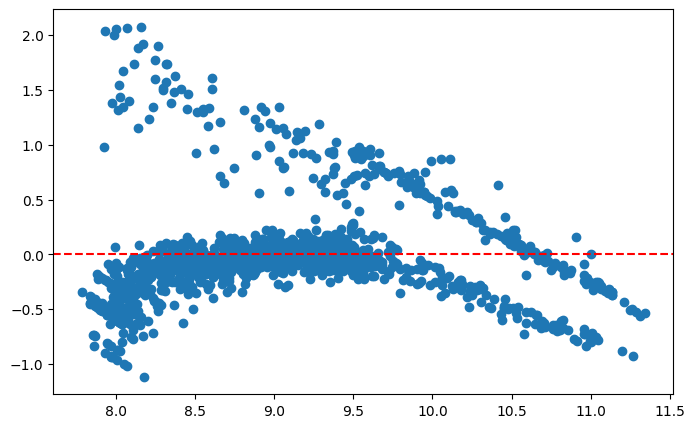

In [15]:
residuals = y_log - log_model.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(log_model.fittedvalues, residuals)
plt.axhline(y=0, color="red", linestyle="--")

In [16]:
# Conclusion: The log transformation slightly improves model fit in terms of R² and significantly changes the interpretation of coefficients from additive effects to multiplicative effects. However, residual patterns suggest remaining non-linearity, indicating that linear regression may still be limited for this dataset.